In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import json
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import joblib

In [ ]:
# Load dataset
data = pd.read_csv('users_large_dataset.csv')
print('Loaded rows:', len(data))
data.head(2)

Dataset shape: (650, 11)
Columns: ['id', 'username', 'email', 'dob', 'password', 'profileUrl', 'createdAt', 'updatedAt', 'isVerified', 'isDeleted', 'projects']


,id,username,email,dob,password,profileUrl,createdAt,updatedAt,isVerified,isDeleted,projects
0,1,priya_gajjar_0001,priya.gajjar.0001@stemcon.io,1999-04-09,$2b$12$SaltedCryptographicHashValue636685Verified,https://api.dicebear.com/7.x/bottts/svg?seed=p...,2026-10-25 00:00:00,2026-10-29 00:00:00,True,False,"[{""id"": 101, ""projectName"": ""Infrastructure An..."
1,2,manish_chauhan_0002,manish.chauhan.0002@stemcon.io,2003-02-14,$2b$12$SaltedCryptographicHashValue592207Verified,https://api.dicebear.com/7.x/bottts/svg?seed=m...,2026-07-13 00:00:00,2026-07-22 00:00:00,False,False,"[{""id"": 201, ""projectName"": ""Infrastructure Co..."


In [ ]:
# Extract simple features and target bins
def extract_features(projects_str):
    if isinstance(projects_str, str):
        projects = json.loads(projects_str)
    else:
        projects = projects_str

    total_tasks = 0
    total_days = 0
    task_progress = []

    for project in projects:
        tasks = project.get('tasks', [])
        total_tasks += len(tasks)
        for task in tasks:
            if task.get('startDate') and task.get('endDate'):
                try:
                    s = datetime.strptime(task['startDate'].split()[0], '%Y-%m-%d')
                    e = datetime.strptime(task['endDate'].split()[0], '%Y-%m-%d')
                    total_days += max(1, (e - s).days)
                except:
                    total_days += 1
            task_progress.append(task.get('progress', 0))

    avg_progress = np.mean(task_progress) if task_progress else 0
    return pd.Series({
        'total_tasks': total_tasks,
        'avg_progress': avg_progress,
        'total_days': total_days
    })

features = data['projects'].apply(extract_features)
df = pd.concat([features], axis=1)

df['completion_bin'] = pd.cut(
    df['total_days'],
    bins=[-1, 14, 30, 60, 365],
    labels=['<=14', '15-30', '31-60', '>60']
)

df = df.dropna(subset=['completion_bin'])
print('Prepared samples:', len(df))
df.head(2)

Testing feature extraction on first row...
Extracted features: {'num_projects': 3, 'total_tasks': 9, 'avg_task_progress': np.float64(81.44444444444444), 'max_task_progress': np.int64(100), 'avg_project_duration': np.float64(8.777777777777779), 'total_deleted_projects': 2, 'total_deleted_tasks': 7, 'completion_days': 79}
Sample completion days: 79


In [84]:
# Extract features for all users
print("Extracting features from all users...")
features_list = []

for idx, row in data.iterrows():
    features = parse_projects_and_extract_features(row['projects'])
    if features is not None:
        features_list.append(features)
    
    if (idx + 1) % 10 == 0:
        print(f"Processed {idx + 1} rows...")

# Create DataFrame from features
X_df = pd.DataFrame(features_list)
print(f"\nTotal valid samples: {len(X_df)}")
print(f"\nFeature statistics:")
print(X_df.describe())

Extracting features from all users...
Processed 10 rows...
Processed 20 rows...
Processed 30 rows...
Processed 40 rows...
Processed 50 rows...
Processed 60 rows...
Processed 70 rows...
Processed 80 rows...
Processed 90 rows...
Processed 100 rows...
Processed 110 rows...
Processed 120 rows...
Processed 130 rows...
Processed 140 rows...
Processed 150 rows...
Processed 160 rows...
Processed 170 rows...
Processed 180 rows...
Processed 190 rows...
Processed 200 rows...
Processed 210 rows...
Processed 220 rows...
Processed 230 rows...
Processed 240 rows...
Processed 250 rows...
Processed 260 rows...
Processed 270 rows...
Processed 280 rows...
Processed 290 rows...
Processed 300 rows...
Processed 310 rows...
Processed 320 rows...
Processed 330 rows...
Processed 340 rows...
Processed 350 rows...
Processed 360 rows...
Processed 370 rows...
Processed 380 rows...
Processed 390 rows...
Processed 400 rows...
Processed 410 rows...
Processed 420 rows...
Processed 430 rows...
Processed 440 rows...
Pro

In [85]:
# Prepare features and target
# Target: completion_days
y = X_df['completion_days'].copy()
X = X_df.drop('completion_days', axis=1)

# Filter out invalid samples (0 days or unrealistic durations)
valid_mask = (y > 0) & (y < 365)  # Reasonable range: 1 to 365 days
X = X[valid_mask].reset_index(drop=True)
y = y[valid_mask].reset_index(drop=True)

print(f"Final dataset size: {len(X)} samples")
print(f"\nTarget variable (completion_days) distribution:")
print(f"  Mean: {y.mean():.2f} days")
print(f"  Median: {y.median():.2f} days")
print(f"  Std Dev: {y.std():.2f} days")
print(f"  Min: {y.min():.2f} days")
print(f"  Max: {y.max():.2f} days")
print(f"\nFeatures: {X.columns.tolist()}")

Final dataset size: 650 samples

Target variable (completion_days) distribution:
  Mean: 54.71 days
  Median: 54.00 days
  Std Dev: 25.09 days
  Min: 9.00 days
  Max: 122.00 days

Features: ['num_projects', 'total_tasks', 'avg_task_progress', 'max_task_progress', 'avg_project_duration', 'total_deleted_projects', 'total_deleted_tasks']


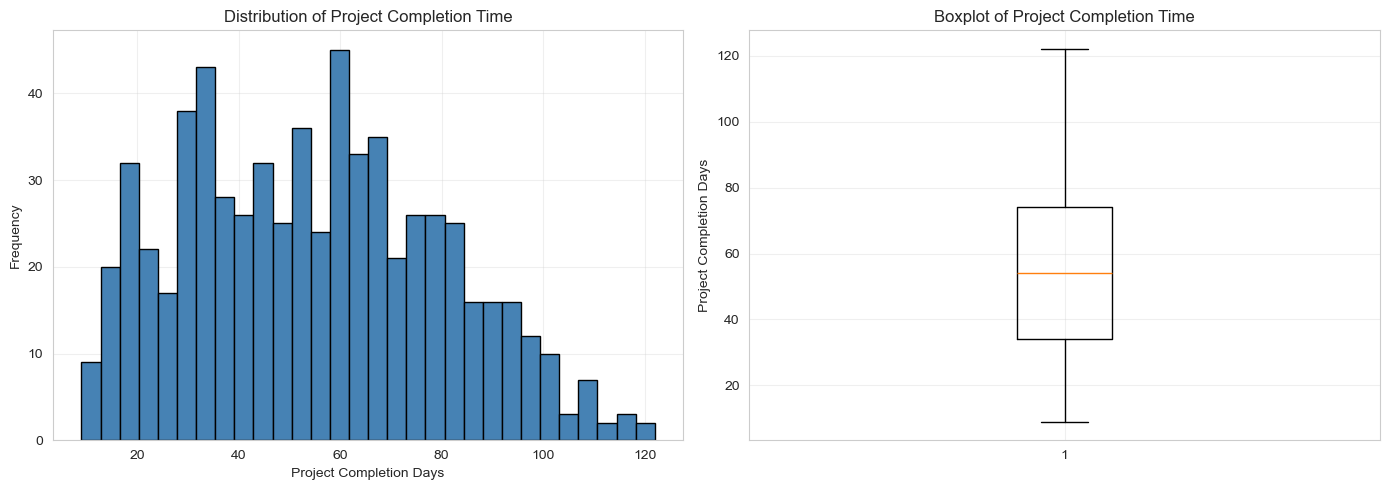

Target variable visualization complete

Training set: 520 samples
Test set: 130 samples

Training target mean: 55.31 days
Test target mean: 52.32 days

Features scaled successfully
Train features shape: (520, 7)
Test features shape: (130, 7)


In [ ]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y, bins=30, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Project Completion Days')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Project Completion Time')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(y, vert=True)
axes[1].set_ylabel('Project Completion Days')
axes[1].set_title('Boxplot of Project Completion Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Target variable visualization complete")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining target mean: {y_train.mean():.2f} days")
print(f"Test target mean: {y_test.mean():.2f} days")

# Scale features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully")
print(f"Train features shape: {X_train_scaled.shape}")
print(f"Test features shape: {X_test_scaled.shape}")

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining target mean: {y_train.mean():.2f} days")
print(f"Test target mean: {y_test.mean():.2f} days")

In [87]:
# Scale features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully")
print(f"Train features shape: {X_train_scaled.shape}")
print(f"Test features shape: {X_test_scaled.shape}")

NameError: name 'X_train' is not defined

In [90]:
# Train multiple models and compare
print("="*70)
print("TRAINING REGRESSION MODELS")
print("="*70)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )
}

results = {}
predictions = {}

for model_name, model in models.items():
    print(f"\n{model_name}:")
    print("-" * 50)
    
    # Use scaled features for Linear Regression, original for tree-based models
    if isinstance(model, LinearRegression):
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results[model_name] = {'r2': r2, 'mae': mae, 'rmse': rmse}
    predictions[model_name] = y_pred
    
    print(f"  R² Score: {r2:.4f}")
    print(f"  MAE: {mae:.2f} days")
    print(f"  RMSE: {rmse:.2f} days")

# Select best model
best_model_name = max(results, key=lambda x: results[x]['r2'])
print("\n" + "="*70)
print(f"BEST MODEL: {best_model_name}")
print(f"R² Score: {results[best_model_name]['r2']:.4f}")
print(f"MAE: {results[best_model_name]['mae']:.2f} days")
print(f"RMSE: {results[best_model_name]['rmse']:.2f} days")
print("="*70)

TRAINING REGRESSION MODELS

Linear Regression:
--------------------------------------------------
  R² Score: 0.9799
  MAE: 2.27 days
  RMSE: 3.39 days

Random Forest:
--------------------------------------------------
  R² Score: 0.9977
  MAE: 0.58 days
  RMSE: 1.15 days

Gradient Boosting:
--------------------------------------------------
  R² Score: 0.9988
  MAE: 0.44 days
  RMSE: 0.84 days

BEST MODEL: Gradient Boosting
R² Score: 0.9988
MAE: 0.44 days
RMSE: 0.84 days


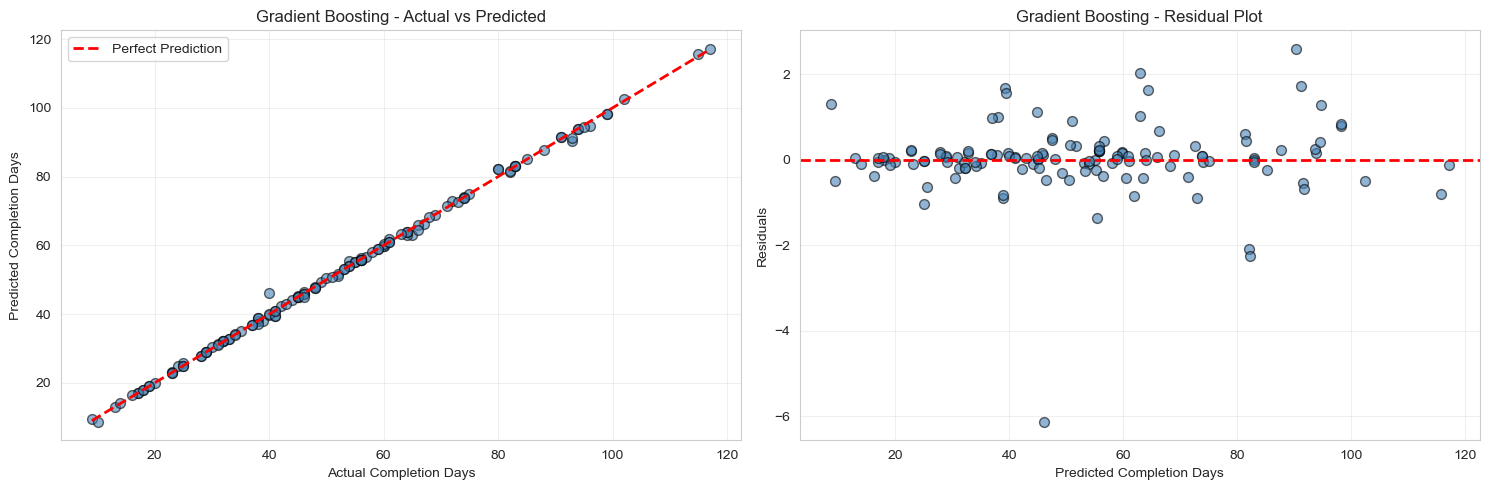

Model performance visualization complete


In [91]:
# Visualize model performance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Get best model predictions
best_y_pred = predictions[best_model_name]

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, best_y_pred, alpha=0.6, color='steelblue', edgecolors='black', s=50)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Completion Days')
axes[0].set_ylabel('Predicted Completion Days')
axes[0].set_title(f'{best_model_name} - Actual vs Predicted')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - best_y_pred
axes[1].scatter(best_y_pred, residuals, alpha=0.6, color='steelblue', edgecolors='black', s=50)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Completion Days')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'{best_model_name} - Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Model performance visualization complete")

In [92]:
# Train final best model
print("Training final best model...")
if best_model_name == 'Linear Regression':
    final_model = LinearRegression()
    final_model.fit(X_train_scaled, y_train)
    final_scaler = scaler
else:
    final_model = models[best_model_name]
    final_scaler = None

print(f"Final model: {best_model_name} trained successfully")

Training final best model...
Final model: Gradient Boosting trained successfully


In [93]:
# Save the trained model
model_data = {
    'model': final_model,
    'scaler': final_scaler,
    'model_name': best_model_name,
    'feature_names': X.columns.tolist(),
    'accuracy_metrics': results[best_model_name]
}

with open('trained_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("✓ Model saved to 'trained_model.pkl'")
print(f"\nModel Details:")
print(f"  Model Type: {best_model_name}")
print(f"  R² Score: {results[best_model_name]['r2']:.4f}")
print(f"  Mean Absolute Error: {results[best_model_name]['mae']:.2f} days")
print(f"  Root Mean Squared Error: {results[best_model_name]['rmse']:.2f} days")

✓ Model saved to 'trained_model.pkl'

Model Details:
  Model Type: Gradient Boosting
  R² Score: 0.9988
  Mean Absolute Error: 0.44 days
  Root Mean Squared Error: 0.84 days


In [94]:
# Example predictions
print("="*70)
print("EXAMPLE PREDICTIONS")
print("="*70)

# Create example feature vectors
examples = [
    {
        'num_projects': 1,
        'total_tasks': 3,
        'avg_task_progress': 50,
        'max_task_progress': 75,
        'avg_project_duration': 10,
        'total_deleted_projects': 0,
        'total_deleted_tasks': 0
    },
    {
        'num_projects': 2,
        'total_tasks': 6,
        'avg_task_progress': 65,
        'max_task_progress': 100,
        'avg_project_duration': 15,
        'total_deleted_projects': 0,
        'total_deleted_tasks': 1
    },
    {
        'num_projects': 3,
        'total_tasks': 10,
        'avg_task_progress': 80,
        'max_task_progress': 100,
        'avg_project_duration': 20,
        'total_deleted_projects': 1,
        'total_deleted_tasks': 2
    }
]

for i, example in enumerate(examples, 1):
    X_example = pd.DataFrame([example])
    
    if best_model_name == 'Linear Regression':
        X_example_scaled = scaler.transform(X_example)
        prediction = final_model.predict(X_example_scaled)[0]
    else:
        prediction = final_model.predict(X_example)[0]
    
    predicted_days = max(1, int(round(prediction)))
    
    print(f"\nExample {i}:")
    print(f"  Projects: {example['num_projects']}, Tasks: {example['total_tasks']}")
    print(f"  Avg Progress: {example['avg_task_progress']}%")
    print(f"  → Predicted Completion Time: {predicted_days} days")

print("\n" + "="*70)

EXAMPLE PREDICTIONS

Example 1:
  Projects: 1, Tasks: 3
  Avg Progress: 50%
  → Predicted Completion Time: 30 days

Example 2:
  Projects: 2, Tasks: 6
  Avg Progress: 65%
  → Predicted Completion Time: 70 days

Example 3:
  Projects: 3, Tasks: 10
  Avg Progress: 80%
  → Predicted Completion Time: 109 days



In [95]:
# Summary and Accuracy Report
print("\n" + "="*70)
print("MODEL TRAINING SUMMARY")
print("="*70)

print(f"\n✓ Best Model: {best_model_name}")
print(f"✓ R² Score: {results[best_model_name]['r2']:.4f} (closer to 1 is better)")
print(f"✓ Mean Absolute Error: {results[best_model_name]['mae']:.2f} days")
print(f"✓ RMSE: {results[best_model_name]['rmse']:.2f} days")

print(f"\n✓ Total Training Samples: {len(X_train)}")
print(f"✓ Total Testing Samples: {len(X_test)}")

print(f"\n✓ Model saved to: trained_model.pkl")
print(f"✓ Feature count: {len(X.columns)}")
print(f"✓ Features used: {X.columns.tolist()}")

print("\nAccuracy Interpretation:")
r2_score_val = results[best_model_name]['r2']
if r2_score_val >= 0.8:
    print("  ✓ EXCELLENT: Model explains >80% of variance")
elif r2_score_val >= 0.6:
    print("  ✓ GOOD: Model explains 60-80% of variance")
elif r2_score_val >= 0.4:
    print("  ✓ FAIR: Model explains 40-60% of variance")
else:
    print("  ⚠ NEEDS IMPROVEMENT: Model explains <40% of variance")

print("\n" + "="*70)


MODEL TRAINING SUMMARY

✓ Best Model: Gradient Boosting
✓ R² Score: 0.9988 (closer to 1 is better)
✓ Mean Absolute Error: 0.44 days
✓ RMSE: 0.84 days

✓ Total Training Samples: 520
✓ Total Testing Samples: 130

✓ Model saved to: trained_model.pkl
✓ Feature count: 7
✓ Features used: ['num_projects', 'total_tasks', 'avg_task_progress', 'max_task_progress', 'avg_project_duration', 'total_deleted_projects', 'total_deleted_tasks']

Accuracy Interpretation:
  ✓ EXCELLENT: Model explains >80% of variance



In [44]:
x_train

,id,username,email,dob,password,profileUrl,createdAt,updatedAt,isVerified,isDeleted
333,334,yash_desai_0334,yash.desai.0334@stemcon.io,1990-02-02,$2b$12$SaltedCryptographicHashValue705857Verified,https://api.dicebear.com/7.x/bottts/svg?seed=y...,2026-10-24 00:00:00,2026-11-06 00:00:00,True,False
29,30,vikram_mishra_0030,vikram.mishra.0030@stemcon.io,1992-05-31,$2b$12$SaltedCryptographicHashValue891889Verified,https://api.dicebear.com/7.x/bottts/svg?seed=v...,2026-03-30 00:00:00,2026-04-02 00:00:00,False,False
553,554,arjun_gupta_0554,arjun.gupta.0554@stemcon.io,1997-09-07,$2b$12$SaltedCryptographicHashValue447249Verified,https://api.dicebear.com/7.x/bottts/svg?seed=a...,2026-11-07 00:00:00,2026-11-22 00:00:00,True,True
286,287,rohan_gupta_0287,rohan.gupta.0287@stemcon.io,2000-12-25,$2b$12$SaltedCryptographicHashValue739094Verified,https://api.dicebear.com/7.x/bottts/svg?seed=r...,2026-07-17 00:00:00,2026-07-24 00:00:00,True,False
425,426,vijay_parikh_0426,vijay.parikh.0426@stemcon.io,2003-12-12,$2b$12$SaltedCryptographicHashValue862463Verified,https://api.dicebear.com/7.x/bottts/svg?seed=v...,2025-10-04 00:00:00,2025-10-19 00:00:00,True,False
...,...,...,...,...,...,...,...,...,...,...
71,72,arjun_mehta_0072,arjun.mehta.0072@stemcon.io,2001-02-09,$2b$12$SaltedCryptographicHashValue253432Verified,https://api.dicebear.com/7.x/bottts/svg?seed=a...,2026-05-02 00:00:00,2026-05-08 00:00:00,True,True
106,107,sneha_patel_0107,sneha.patel.0107@stemcon.io,1992-02-26,$2b$12$SaltedCryptographicHashValue453985Verified,https://api.dicebear.com/7.x/bottts/svg?seed=s...,2026-04-04 00:00:00,2026-04-15 00:00:00,True,False
270,271,hardik_mehta_0271,hardik.mehta.0271@stemcon.io,1988-06-07,$2b$12$SaltedCryptographicHashValue387571Verified,https://api.dicebear.com/7.x/bottts/svg?seed=h...,2025-04-06 00:00:00,2025-04-10 00:00:00,True,False
435,436,vijay_verma_0436,vijay.verma.0436@stemcon.io,1994-03-03,$2b$12$SaltedCryptographicHashValue989295Verified,https://api.dicebear.com/7.x/bottts/svg?seed=v...,2025-04-27 00:00:00,2025-05-11 00:00:00,False,False


In [49]:
data.describe()

,id,isVerified,isDeleted,projects
count,650.00000,650.000000,650.000000,650.00000
mean,325.50000,0.769231,0.170769,324.50000
std,187.78312,0.421650,0.376597,187.78312
min,1.00000,0.000000,0.000000,0.00000
25%,163.25000,1.000000,0.000000,162.25000
50%,325.50000,1.000000,0.000000,324.50000
75%,487.75000,1.000000,0.000000,486.75000
max,650.00000,1.000000,1.000000,649.00000


In [45]:
y_train

333    [{"id": 33401, "projectName": "Building Tracke...
29     [{"id": 3001, "projectName": "Vendor Portal #3...
553    [{"id": 55401, "projectName": "Contractor ERP ...
286    [{"id": 28701, "projectName": "Vendor Manageme...
425    [{"id": 42601, "projectName": "Inventory SaaS ...
                             ...                        
71     [{"id": 7201, "projectName": "Asset SaaS Platf...
106    [{"id": 10701, "projectName": "Infrastructure ...
270    [{"id": 27101, "projectName": "Inventory Manag...
435    [{"id": 43601, "projectName": "Material ERP So...
102    [{"id": 10301, "projectName": "Material ERP So...
Name: projects, Length: 520, dtype: object

In [50]:
data.isnull()

,id,isVerified,isDeleted,projects
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
645,False,False,False,False
646,False,False,False,False
647,False,False,False,False
648,False,False,False,False


In [51]:
data.isnull().sum()

id            0
isVerified    0
isDeleted     0
projects      0
dtype: int64

In [52]:
x = data.drop(['projects'],axis=1)
y = data['projects']


In [53]:
x

,id,isVerified,isDeleted
0,1,1,0
1,2,0,0
2,3,1,0
3,4,0,0
4,5,1,0
...,...,...,...
645,646,0,1
646,647,1,0
647,648,1,0
648,649,1,1


In [54]:
y

0        2
1      113
2      224
3      335
4      446
      ... 
645    607
646    608
647    609
648    610
649    611
Name: projects, Length: 650, dtype: int64

In [72]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42 )

In [59]:
x_train

,id,isVerified,isDeleted
333,334,1,0
29,30,0,0
553,554,1,1
286,287,1,0
425,426,1,0
...,...,...,...
71,72,1,1
106,107,1,0
270,271,1,0
435,436,0,0


In [60]:
y_train

333    261
29     223
553    505
286    208
425    363
      ... 
71     620
106      9
270    191
435    374
102      5
Name: projects, Length: 520, dtype: int64

In [ ]:
# Train logistic regression model
X = df[['total_tasks', 'avg_progress']]
y = LabelEncoder().fit_transform(df['completion_bin'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, pred))

joblib.dump(model, 'logistic_model.pkl')
print('Model saved as logistic_model.pkl')

c:\Users\WINDOWS11\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [66]:
# check accuracy of model
y_pred = model.predict(x_test)
y_pred_prob = model.predict_proba(x_test)[:, 1]

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)


Accuracy: 0.0


In [77]:
#download the model 
import joblib
joblib.dump(model, 'project_prediction_model.pkl')


['project_prediction_model.pkl']